In [ ]:
import numpy as np                        # numerical arrays
import pandas as pd                         # tables
import matplotlib.pyplot as plt             # plots
from sklearn.model_selection import train_test_split          # split data
from sklearn.ensemble import RandomForestClassifier           # a flexible "black box" model
from sklearn.linear_model import LinearRegression             # simple model for local surrogate
from sklearn.metrics import accuracy_score                    # accuracy
from sklearn.inspection import permutation_importance, PartialDependenceDisplay  # explainers
np.random.seed(0)                           # reproducibility

In [ ]:
n = 2000                                            # number of applicants
rng = np.random.RandomState(0)                      # a fixed random generator

group    = rng.randint(0, 2, n)                     # protected attribute: 0 or 1
income   = rng.normal(50, 15, n)                    # income (thousands)
credit   = rng.normal(600, 80, n)                   # credit score
loan_amt = rng.normal(200, 60, n)                   # requested loan amount

# A genuine creditworthiness signal: income & credit help, big loans hurt
score = 0.04*income + 0.01*credit - 0.012*loan_amt + rng.normal(0, 1, n)

# HISTORICAL BIAS: subtract a penalty from group 0 that has nothing to do with repaying
score = score - 1.2 * (group == 0)                  # unfairly pushes group 0 down

approved = (score > np.median(score)).astype(int)   # label: 1 = approved, 0 = denied
# Put everything into a tidy table
df = pd.DataFrame({"income": income, "credit": credit, "loan_amt": loan_amt,
                   "group": group, "approved": approved})
print(df.head())                                    # peek at the first rows

# The unfairness is already visible in the LABELS, before any model exists
print("\nApproval rate by group (in the raw data):")
print(df.groupby("group")["approved"].mean().round(2))

      income      credit    loan_amt  group  approved
0  48.474541  506.844124  264.536197      0         0
1  50.289191  497.718893  223.004168      1         1
2  77.743869  516.414694  111.980152      1         1
3  46.787500  663.192395  184.113094      0         1
4  42.514750  688.182605  138.075259      1         1

Approval rate by group (in the raw data):
group
0    0.35
1    0.64
Name: approved, dtype: float64


In [ ]:
correlation = df['income'].corr(df['approved'])
print(f"Correlation between income and approved status: {correlation:.2f}")

Correlation between income and approved status: 0.26


In [ ]:
features = ["income", "credit", "loan_amt", "group"]   # model inputs (we include group on purpose)
X = df[features]                                       # feature table
y = df["approved"]                                     # target

# Train / test split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0)

# Train a flexible model — our "black box"
clf = RandomForestClassifier(n_estimators=120, random_state=0).fit(X_tr, y_tr)

# Probabilities and default (0.5-threshold) decisions on the test set
proba = clf.predict_proba(X_te)[:, 1]                  # P(approve) for each test applicant
pred  = (proba >= 0.5).astype(int)                     # default decision
print(f"Overall accuracy: {accuracy_score(y_te, pred):.3f}")

def fairness_report(X_eval, y_true, y_pred):           # compute per-group fairness numbers
    g = X_eval["group"].values                         # protected attribute for these rows
    out = {}                                            # results: group -> (approval_rate, TPR)
    for grp in [0, 1]:                                  # for each group
        m = (g == grp)                                  # mask of rows in this group
        approval_rate = y_pred[m].mean()                # P(predict approve) -> demographic parity
        tpr = y_pred[m][y_true[m] == 1].mean()          # recall on truly-approved -> equal opp.
        out[grp] = (approval_rate, tpr)                 # store both
    return out

rep = fairness_report(X_te, y_te.values, pred)          # measure on test predictions
dp_gap = abs(rep[0][0] - rep[1][0])                     # demographic-parity gap
eo_gap = abs(rep[0][1] - rep[1][1])                     # equal-opportunity gap

print(f"\nGroup 0  approval={rep[0][0]:.2f}  TPR={rep[0][1]:.2f}")
print(f"Group 1  approval={rep[1][0]:.2f}  TPR={rep[1][1]:.2f}")
print(f"\nDemographic-parity gap : {dp_gap:.2f}   (0 = equal approval rates)")
print(f"Equal-opportunity gap  : {eo_gap:.2f}   (0 = equal recall)")
print("\nNote: usually you can't make BOTH gaps zero at once — pick the one that fits the context.")

Overall accuracy: 0.793

Group 0  approval=0.34  TPR=0.66
Group 1  approval=0.68  TPR=0.86

Demographic-parity gap : 0.34   (0 = equal approval rates)
Equal-opportunity gap  : 0.21   (0 = equal recall)

Note: usually you can't make BOTH gaps zero at once — pick the one that fits the context.


In [ ]:
rep = fairness_report(X_te, y_te.values, pred)          # measure on test predictions
dp_gap = abs(rep[0][0] - rep[1][0])                     # demographic-parity gap
eo_gap = abs(rep[0][1] - rep[1][1])                     # equal-opportunity gap

print(f"\nGroup 0  approval={rep[0][0]:.2f}  TPR={rep[0][1]:.2f}")
print(f"Group 1  approval={rep[1][0]:.2f}  TPR={rep[1][1]:.2f}")
print(f"\nDemographic-parity gap : {dp_gap:.2f}   (0 = equal approval rates)")
print(f"Equal-opportunity gap  : {eo_gap:.2f}   (0 = equal recall)")
print("\nNote: usually you can't make BOTH gaps zero at once — pick the one that fits the context.")


Group 0  approval=0.34  TPR=0.66
Group 1  approval=0.68  TPR=0.86

Demographic-parity gap : 0.34   (0 = equal approval rates)
Equal-opportunity gap  : 0.21   (0 = equal recall)

Note: usually you can't make BOTH gaps zero at once — pick the one that fits the context.


In [ ]:
i = 5                                                  # index of the applicant we want to explain
x0 = X_te.iloc[i].values.astype(float)                # that applicant's feature vector

def p_approve(vec):                                   # helper: model's approval prob for one vector
    row = pd.DataFrame([vec], columns=features)       # wrap as a 1-row DataFrame (keeps feature names)
    return clf.predict_proba(row)[0, 1]               # return P(approve)

print("Explaining applicant:", {f: round(v, 1) for f, v in zip(features, x0)})
print("Model approval probability:", round(p_approve(x0), 3))

# We explain only the CHANGEABLE features; we don't ask someone to change a protected attribute
expl_features = ["income", "credit", "loan_amt"]       # features we vary locally
idx = [features.index(f) for f in expl_features]       # their column positions
scales = np.array([8.0, 40.0, 30.0])                   # how much to jitter each one

m = 500                                                # number of perturbed neighbours
deltas = rng.normal(0, scales, size=(m, 3))            # random local changes to the 3 features
neigh = np.tile(x0, (m, 1))                            # 500 copies of the applicant
neigh[:, idx] += deltas                                # apply the changes (group stays fixed)
neigh_df = pd.DataFrame(neigh, columns=features)       # as a DataFrame (keeps feature names)
neigh_proba = clf.predict_proba(neigh_df)[:, 1]        # black-box output for each neighbour
# Fit a simple LINEAR surrogate: local feature change -> change in approval probability
surrogate = LinearRegression().fit(deltas, neigh_proba)

# Per-unit weights, plus a "typical local impact" = weight x jitter-scale (comparable across features)
print("\nLocal explanation (positive -> pushes toward APPROVAL):")
rows = list(zip(expl_features, surrogate.coef_, surrogate.coef_ * scales))
for f, w, impact in sorted(rows, key=lambda t: -abs(t[2])):   # biggest local impact first
    print(f"  {f:9s}: weight per unit = {w:+.4f}   typical local impact = {impact:+.3f}")

Explaining applicant: {'income': np.float64(50.6), 'credit': np.float64(553.0), 'loan_amt': np.float64(228.4), 'group': np.float64(1.0)}
Model approval probability: 0.408

Local explanation (positive -> pushes toward APPROVAL):
  loan_amt : weight per unit = -0.0051   typical local impact = -0.154
  credit   : weight per unit = +0.0037   typical local impact = +0.147
  income   : weight per unit = +0.0110   typical local impact = +0.088


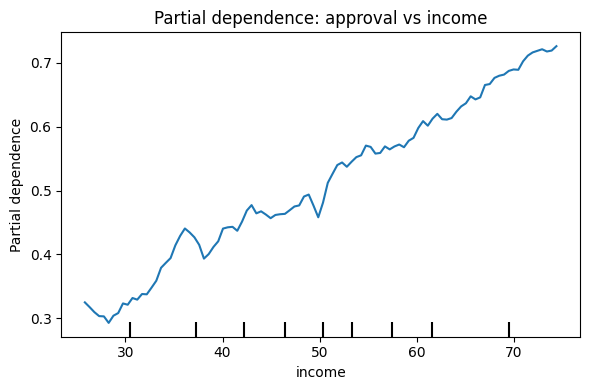

The curve shows where rising income starts to change the model's approvals.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))                 # figure + axis
PartialDependenceDisplay.from_estimator(clf, X_te, ["income"], ax=ax)  # PDP for "income"
ax.set_title("Partial dependence: approval vs income")  # title
plt.tight_layout(); plt.show()                          # draw
print("The curve shows where rising income starts to change the model's approvals.")

In [ ]:
denied = np.where(pred == 0)[0]                        # indices the model denied
j = denied[0]                                          # take the first denied applicant
x = X_te.iloc[j].values.astype(float).copy()           # an editable copy of their features

base_p = p_approve(x)                                  # their starting approval probability
print(f"Applicant denied: P(approve)={base_p:.2f}, income={x[0]:.1f}k")

step, bump = 1.0, 0.0                                   # raise income 1k at a time; track total
while p_approve(x) < 0.5 and bump < 120:               # keep going until the decision flips (or give up)
    x[0]  += step                                      # increase the income feature
    bump  += step                                      # remember how much we've added

if p_approve(x) >= 0.5:                                 # did we manage to flip it?
    print(f"Counterfactual: raise income by ~{bump:.0f}k  ->  APPROVED (P={p_approve(x):.2f})")
else:
    print("Income alone did not flip this decision within the search range.")

Applicant denied: P(approve)=0.12, income=32.6k
Counterfactual: raise income by ~34k  ->  APPROVED (P=0.56)
